The purpose of this is to check how linear the pixel to sky relations are to see if the world coordinates need to be calculated in inner vs outer loops. See [wcs_mappings.ipynb](wcs_mappings.ipynb) for more general wcs exploartion

In [2]:
from pathlib import Path

import numpy as np

from matplotlib import pyplot as plt

import gwcs
from scipy.stats import linregress
from jwst import datamodels

from astropy import units as u
from astropy.coordinates import SkyCoord, SpectralCoord

In [3]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))
n6791dms = [datamodels.open(fn) for fn in n6791fits]

dm0 = n6791dms[0]
s = dm0.slits[42]
swcs = s.meta.wcs

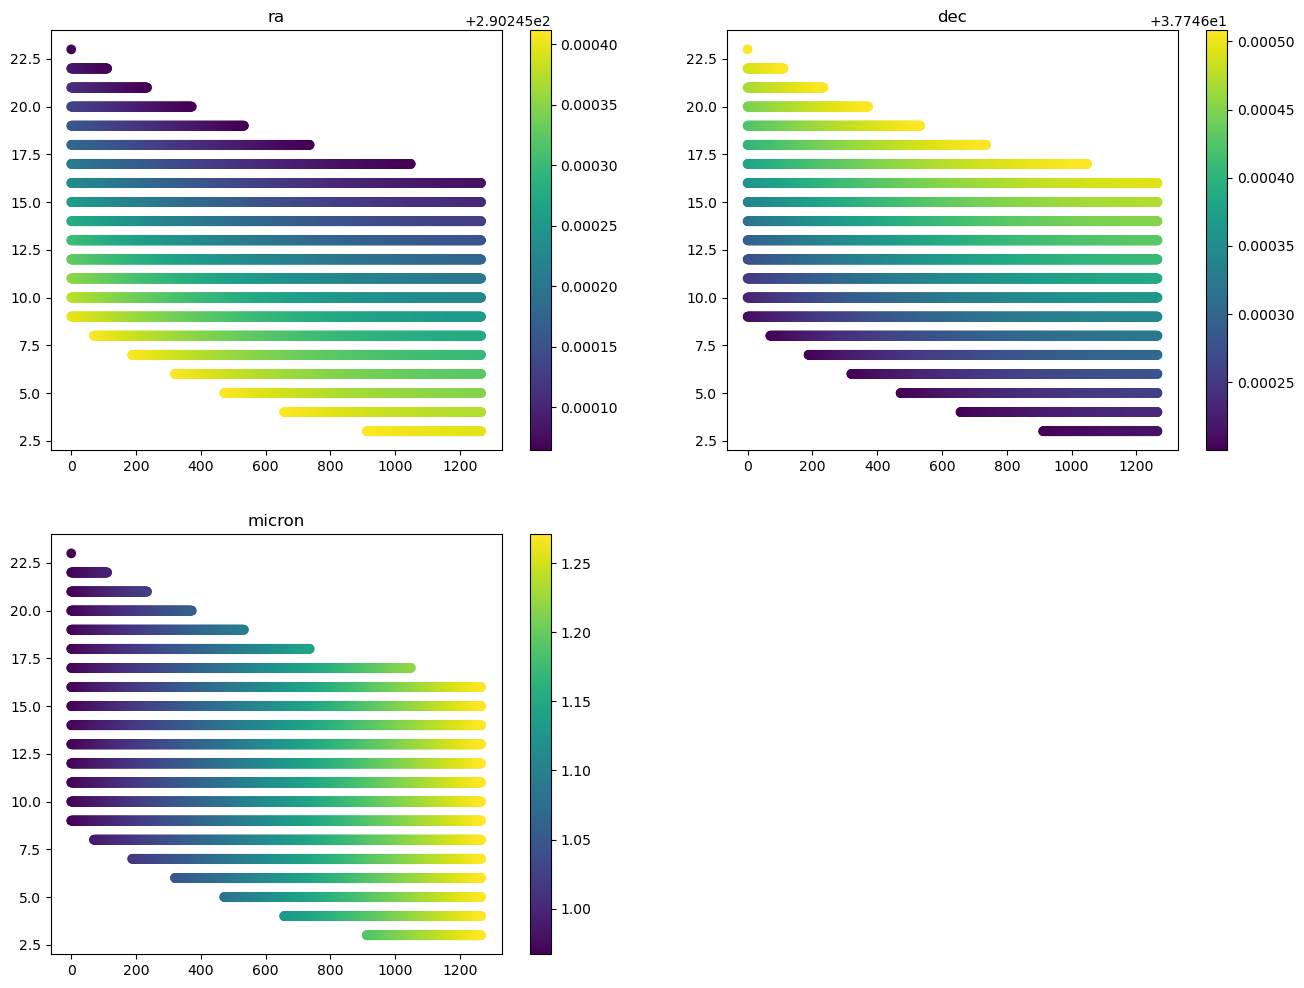

In [4]:
yp, xp = np.indices(s.data.shape)
sky, spec = swcs.pixel_to_world(xp, yp)

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

ax = axs.ravel()[0]
sc = ax.scatter(xp, yp, c=sky.ra.deg)
ax.set_title('ra')
plt.colorbar(sc, ax=ax)

ax = axs.ravel()[1]
sc = ax.scatter(xp, yp, c=sky.dec.deg)
ax.set_title('dec')
plt.colorbar(sc, ax=ax)

ax = axs.ravel()[2]
sc = ax.scatter(xp, yp, c=spec.to_value(u.micron))
ax.set_title('micron')
plt.colorbar(sc, ax=ax)

axs.ravel()[3].remove()

In [5]:
xpm = np.nanmedian(xp.ravel())
dxp = xp - xpm

ypm = np.nanmedian(yp.ravel())
dyp = yp - ypm

skymed, specmed = swcs.pixel_to_world(xpm, ypm)
dra = sky.ra.deg - skymed.ra.deg
ddec = sky.dec.deg - skymed.dec.deg
dspec = (spec - specmed).to_value(u.micron)

xpm, ypm, skymed, specmed

(np.float64(632.5),
 np.float64(12.0),
 <SkyCoord (ICRS): (ra, dec) in deg
     (290.24522108, 37.74636915)>,
 <SpectralCoord 1.11929929 um>)

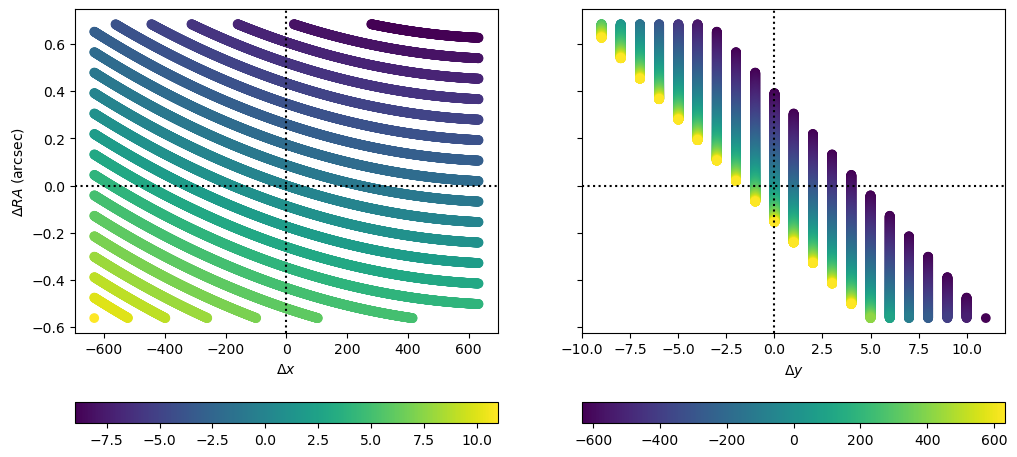

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

sc1 = ax1.scatter(dxp, dra*3600, c=dyp)
plt.colorbar(sc1, ax=ax1, orientation='horizontal')

sc2 = ax2.scatter(dyp, dra*3600, c=dxp)
plt.colorbar(sc2, ax=ax2, orientation='horizontal')

for ax in (ax1, ax2):
    ax.axhline(0, c='k', ls=':')
    ax.axvline(0, c='k', ls=':')

ax1.set_ylabel(r'$\Delta RA$ (arcsec)')
ax1.set_xlabel(r'$\Delta x$')
ax2.set_xlabel(r'$\Delta y$');

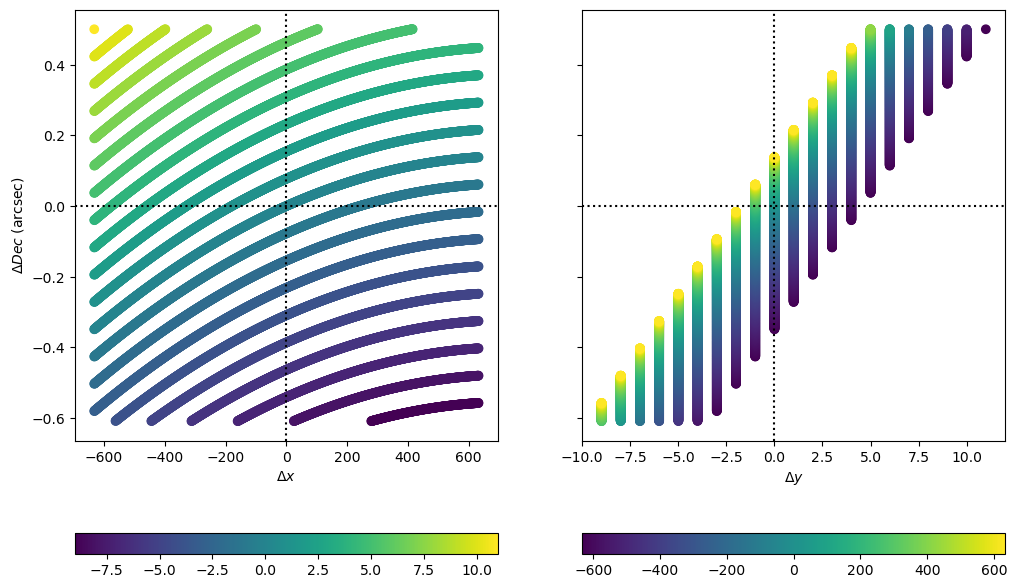

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

sc1 = ax1.scatter(dxp, ddec*3600, c=dyp)
plt.colorbar(sc1, ax=ax1, orientation='horizontal')

sc2 = ax2.scatter(dyp, ddec*3600, c=dxp)
plt.colorbar(sc2, ax=ax2, orientation='horizontal')

for ax in (ax1, ax2):
    ax.axhline(0, c='k', ls=':')
    ax.axvline(0, c='k', ls=':')
    
ax1.set_ylabel(r'$\Delta Dec$ (arcsec)')
ax1.set_xlabel(r'$\Delta x$')
ax2.set_xlabel(r'$\Delta y$');

Text(0.5, 0, '$\\Delta y$')

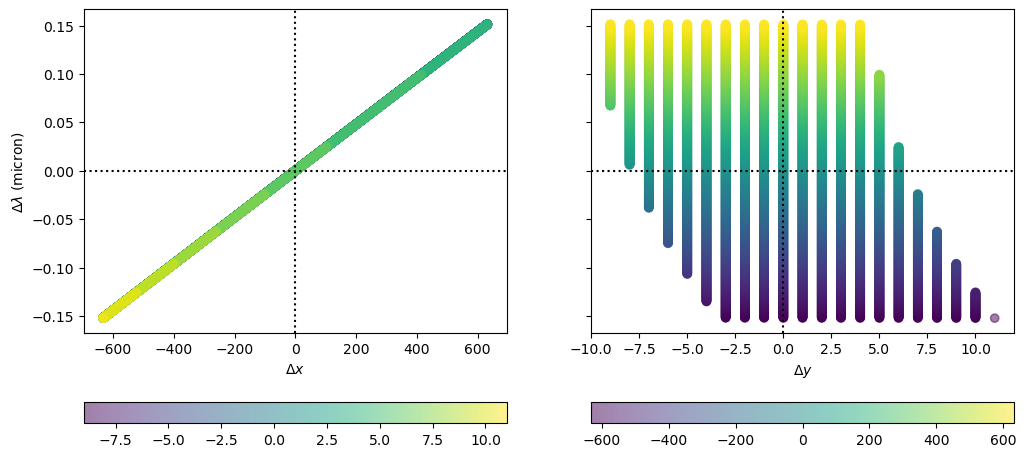

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

sc1 = ax1.scatter(dxp, dspec, c=dyp, alpha=.5)
plt.colorbar(sc1, ax=ax1, orientation='horizontal')

sc2 = ax2.scatter(dyp, dspec, c=dxp, alpha=.5)
plt.colorbar(sc2, ax=ax2, orientation='horizontal')

for ax in (ax1, ax2):
    ax.axhline(0, c='k', ls=':')
    ax.axvline(0, c='k', ls=':')

ax1.set_ylabel(r'$\Delta \lambda$ (micron)')
ax1.set_xlabel(r'$\Delta x$')
ax2.set_xlabel(r'$\Delta y$')

Now consider a small region around the median

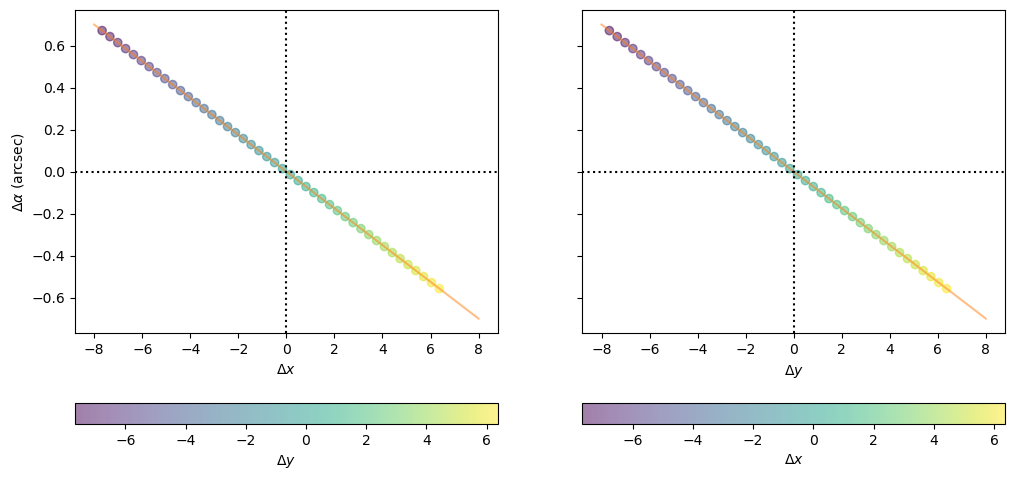

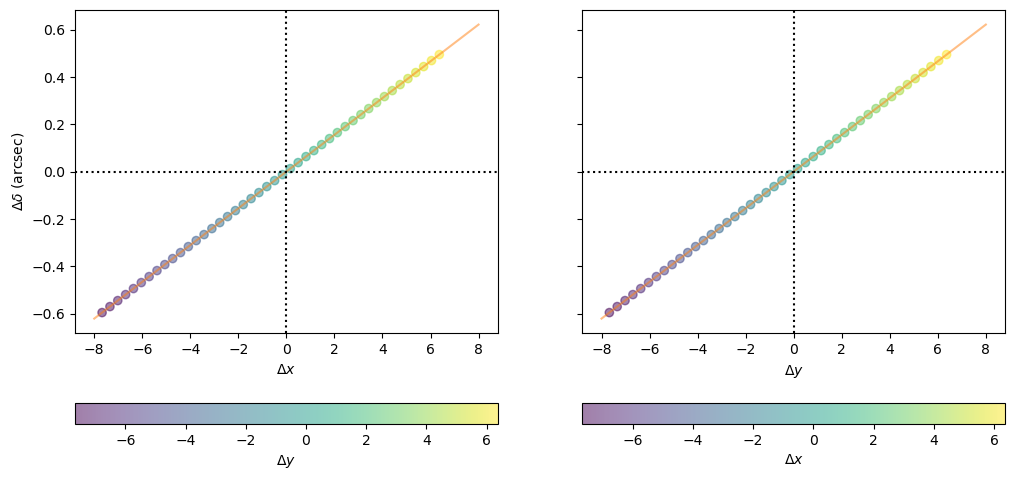

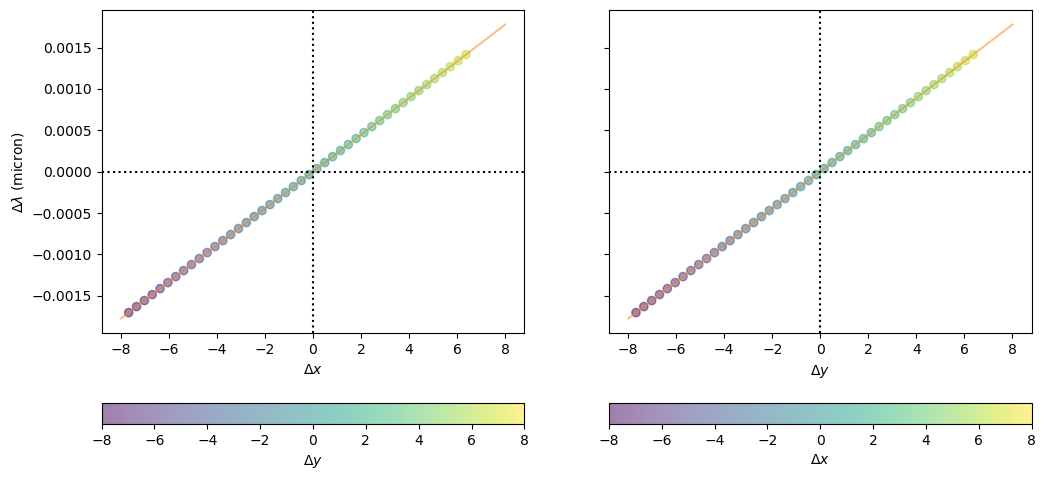

In [9]:
dx = xpm + np.linspace(-8, 8, 50)
dy = ypm + np.linspace(-8, 8, 50)

dsky, dspec = swcs.pixel_to_world(dx, dy)

for d, nm in [((dsky.ra.deg - skymed.ra.deg)*3600, r'$\Delta \alpha$ (arcsec)'),
              ((dsky.dec.deg - skymed.dec.deg)*3600, r'$\Delta \delta$ (arcsec)'),
              (dspec - specmed, r'$\Delta \lambda$ (micron)'),
              ]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    xx = dx - xpm
    yy = dy - ypm
    zz = d
    msk = np.isfinite(xx)&np.isfinite(yy)&np.isfinite(zz)

    sc1 = ax1.scatter(xx, zz, c=yy, alpha=.5)
    lres = linregress(xx[msk], zz[msk])
    ax1.plot(xx, lres.slope* xx + lres.intercept, c='C1', alpha=.5)
    plt.colorbar(sc1, ax=ax1, orientation='horizontal').set_label(r'$\Delta y$')
    ax1.set_xlabel(r'$\Delta x$')


    sc2 = ax2.scatter(yy, zz, c=xx, alpha=.5)
    ax2.plot(yy, lres.slope* yy + lres.intercept, c='C1', alpha=.5)
    lres = linregress(yy[msk], zz[msk])
    plt.colorbar(sc2, ax=ax2, orientation='horizontal').set_label(r'$\Delta x$')
    ax2.set_xlabel(r'$\Delta y$')

    for ax in (ax1, ax2):
        ax.axhline(0, c='k', ls=':')
        ax.axvline(0, c='k', ls=':')

    ax1.set_ylabel(nm)

Now consider the inverse operation - small shifts in ra/dec (at fixed wavelength) and how that corresponds to shifts in pixels

(<SpectralCoord 1.11929929 um>, np.float64(632.5), np.float64(12.0))

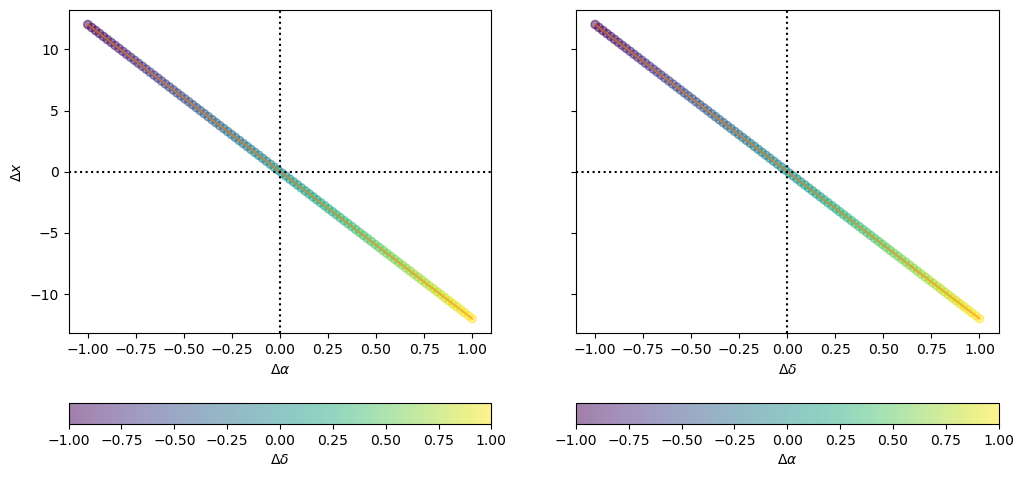

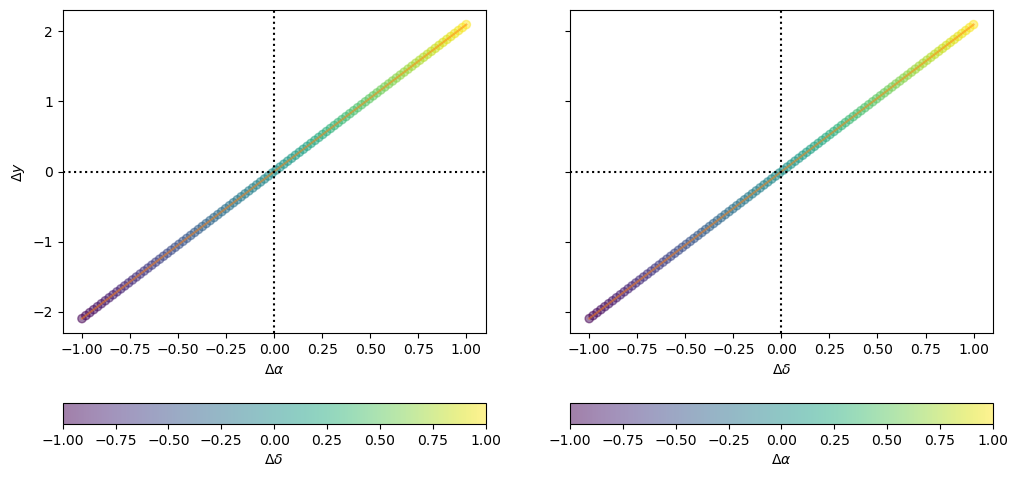

In [10]:
dsky = SkyCoord(ra=np.linspace(-1, 1, 100)*u.arcsec + skymed.ra, dec=np.linspace(-1, 1, 100)*u.arcsec + skymed.dec)
dra = dsky.ra.arcsec - skymed.ra.arcsec
ddec = dsky.dec.arcsec - skymed.dec.arcsec
xs, ys = swcs.world_to_pixel(dsky, specmed)

for zz, nm in [(xs - xpm, r'$\Delta x$'),
              (ys - ypm, r'$\Delta y$'),
              ]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    msk = np.isfinite(dra)&np.isfinite(ddec)&np.isfinite(zz)

    sc1 = ax1.scatter(dra, zz, c=ddec, alpha=.5)
    lres = linregress(dra[msk], zz[msk])
    ax1.plot(dra, lres.slope*dra + lres.intercept, c='C1', alpha=.5)
    plt.colorbar(sc1, ax=ax1, orientation='horizontal').set_label(r'$\Delta \delta$')
    ax1.set_xlabel(r'$\Delta \alpha$')


    sc2 = ax2.scatter(ddec, zz, c=dra, alpha=.5)
    ax2.plot(ddec, lres.slope* ddec + lres.intercept, c='C1', alpha=.5)
    lres = linregress(ddec[msk], zz[msk])
    plt.colorbar(sc2, ax=ax2, orientation='horizontal').set_label(r'$\Delta \alpha$')
    ax2.set_xlabel(r'$\Delta \delta$')

    for ax in (ax1, ax2):
        ax.axhline(0, c='k', ls=':')
        ax.axvline(0, c='k', ls=':')

    ax1.set_ylabel(nm)

specmed, xpm, ypm

In [11]:
spectests = np.linspace(np.nanmin(spec), np.nanmax(spec), 7)

(<SpectralCoord 1.01761675 um>, 209.70681084473176, 14.710289485676697)

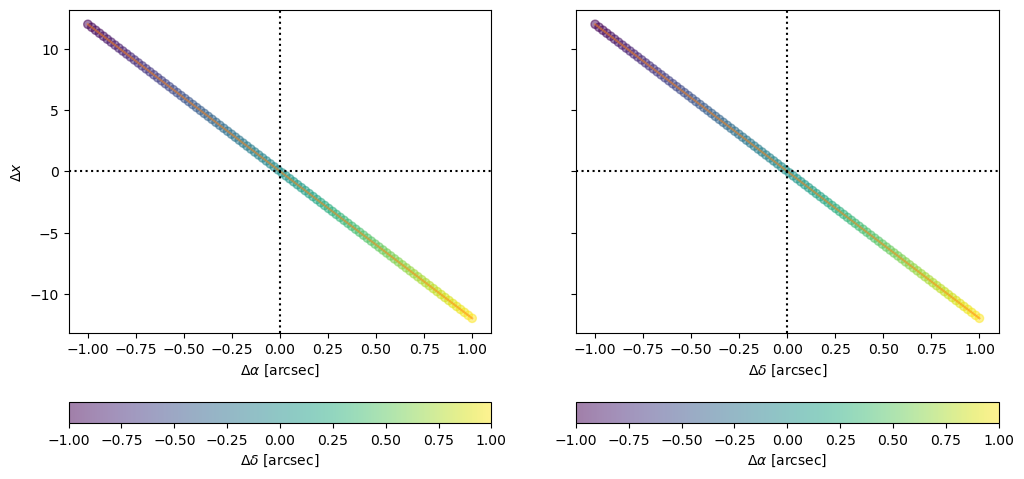

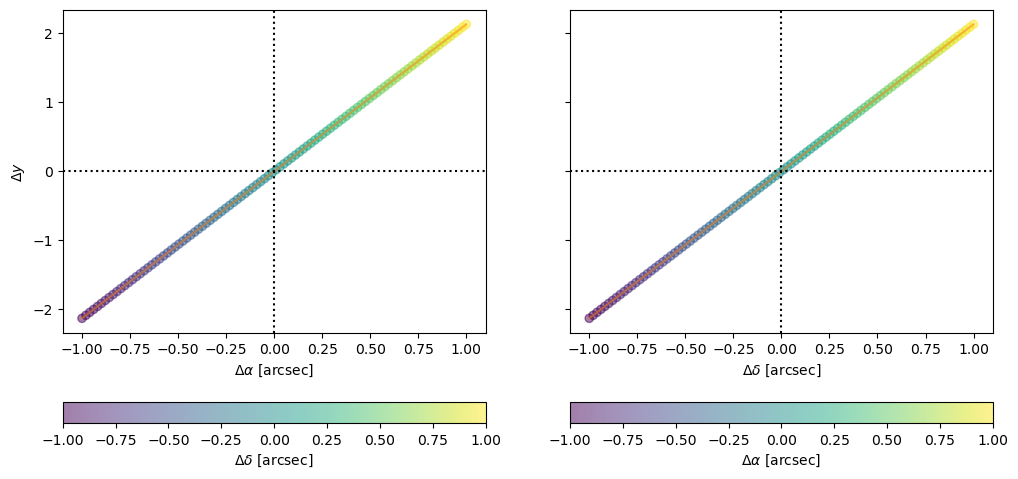

In [12]:
thisspeccoo = spectests[1]

dsky = SkyCoord(ra=np.linspace(-1, 1, 100)*u.arcsec + skymed.ra, dec=np.linspace(-1, 1, 100)*u.arcsec + skymed.dec)
dra = dsky.ra.arcsec - skymed.ra.arcsec
ddec = dsky.dec.arcsec - skymed.dec.arcsec
xs, ys = swcs.world_to_pixel(dsky, thisspeccoo)
xcen, ycen = swcs.world_to_pixel(skymed, thisspeccoo)

for zz, nm in [(xs - xcen, r'$\Delta x$'),
              (ys - ycen, r'$\Delta y$'),
              ]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    msk = np.isfinite(dra)&np.isfinite(ddec)&np.isfinite(zz)

    sc1 = ax1.scatter(dra, zz, c=ddec, alpha=.5)
    lres = linregress(dra[msk], zz[msk])
    ax1.plot(dra, lres.slope*dra + lres.intercept, c='C1', alpha=.5)
    plt.colorbar(sc1, ax=ax1, orientation='horizontal').set_label(r'$\Delta \delta$ [arcsec]')
    ax1.set_xlabel(r'$\Delta \alpha$ [arcsec]')


    sc2 = ax2.scatter(ddec, zz, c=dra, alpha=.5)
    ax2.plot(ddec, lres.slope* ddec + lres.intercept, c='C1', alpha=.5)
    lres = linregress(ddec[msk], zz[msk])
    plt.colorbar(sc2, ax=ax2, orientation='horizontal').set_label(r'$\Delta \alpha$ [arcsec]')
    ax2.set_xlabel(r'$\Delta \delta$ [arcsec]')

    for ax in (ax1, ax2):
        ax.axhline(0, c='k', ls=':')
        ax.axvline(0, c='k', ls=':')

    ax1.set_ylabel(nm)
thisspeccoo, xcen, ycen

(<SpectralCoord 1.22024231 um>, 1053.6290547996782, 10.513952239209345)

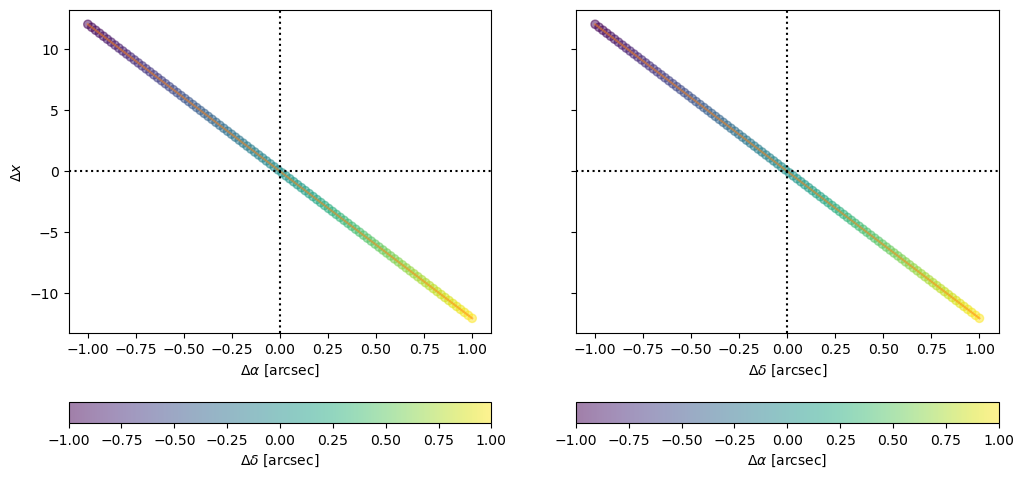

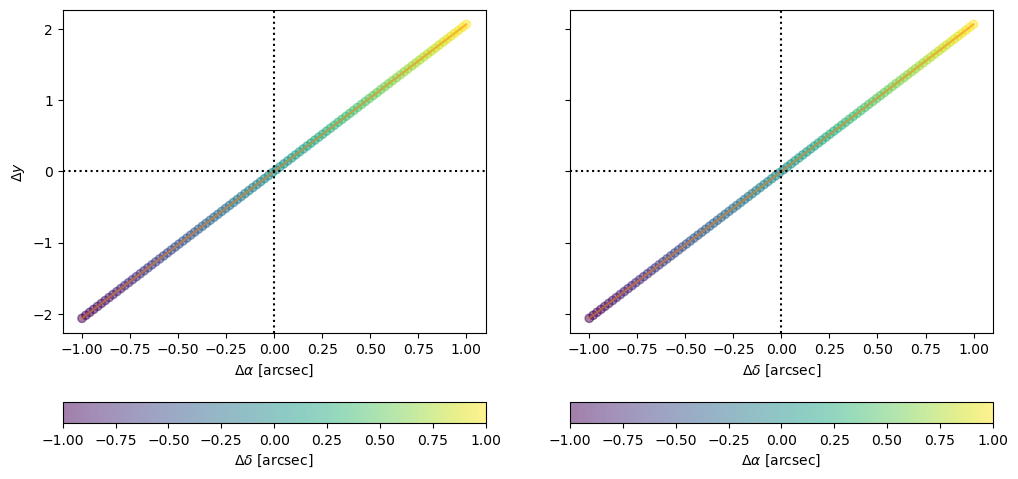

In [13]:
thisspeccoo = spectests[-2]

dsky = SkyCoord(ra=np.linspace(-1, 1, 100)*u.arcsec + skymed.ra, dec=np.linspace(-1, 1, 100)*u.arcsec + skymed.dec)
dra = dsky.ra.arcsec - skymed.ra.arcsec
ddec = dsky.dec.arcsec - skymed.dec.arcsec
xs, ys = swcs.world_to_pixel(dsky, thisspeccoo)
xcen, ycen = swcs.world_to_pixel(skymed, thisspeccoo)

for zz, nm in [(xs - xcen, r'$\Delta x$'),
              (ys - ycen, r'$\Delta y$'),
              ]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    msk = np.isfinite(dra)&np.isfinite(ddec)&np.isfinite(zz)

    sc1 = ax1.scatter(dra, zz, c=ddec, alpha=.5)
    lres = linregress(dra[msk], zz[msk])
    ax1.plot(dra, lres.slope*dra + lres.intercept, c='C1', alpha=.5)
    plt.colorbar(sc1, ax=ax1, orientation='horizontal').set_label(r'$\Delta \delta$ [arcsec]')
    ax1.set_xlabel(r'$\Delta \alpha$ [arcsec]')


    sc2 = ax2.scatter(ddec, zz, c=dra, alpha=.5)
    ax2.plot(ddec, lres.slope* ddec + lres.intercept, c='C1', alpha=.5)
    lres = linregress(ddec[msk], zz[msk])
    plt.colorbar(sc2, ax=ax2, orientation='horizontal').set_label(r'$\Delta \alpha$ [arcsec]')
    ax2.set_xlabel(r'$\Delta \delta$ [arcsec]')

    for ax in (ax1, ax2):
        ax.axhline(0, c='k', ls=':')
        ax.axvline(0, c='k', ls=':')

    ax1.set_ylabel(nm)
thisspeccoo, xcen, ycen

All looks linear so we can just sneak it into the pixel offsets.  Does the same hold for wave offsets?

(<SpectralCoord 1.11929929 um>, np.float64(632.5), np.float64(12.0))

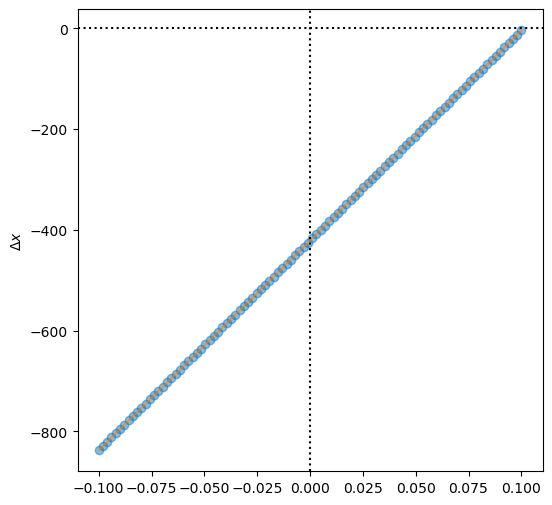

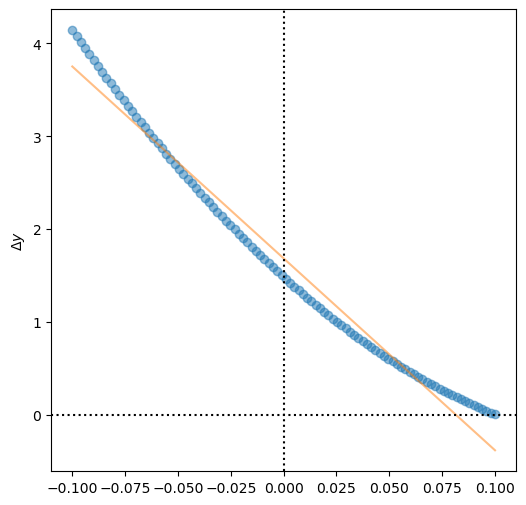

In [14]:
dspec = np.linspace(-0.1, 0.1, 100)*u.micron
xs, ys = swcs.world_to_pixel(skymed, SpectralCoord(specmed + dspec))

for zz, nm in [(xs - xcen, r'$\Delta x$'),
              (ys - ycen, r'$\Delta y$'),
              ]:
    fig, ax1 = plt.subplots(1, 1, figsize=(6, 6), sharey=True)

    msk = np.isfinite(dra)&np.isfinite(ddec)&np.isfinite(zz)

    sc1 = ax1.scatter(dspec.value, zz, alpha=.5)
    lres = linregress(dspec.value[msk], zz[msk])
    ax1.plot(dspec.value, lres.slope*dspec.value + lres.intercept, c='C1', alpha=.5)
    ax1.set_xlabel('')

    for ax in (ax1, ):
        ax.axhline(0, c='k', ls=':')
        ax.axvline(0, c='k', ls=':')

    ax1.set_ylabel(nm)

specmed, xpm, ypm

Aha, so it's not linear with wavelength.